![tasks](../docs/tasks.png)


# SVMモデルの構築

In [10]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from datetime import datetime
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, roc_auc_score, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree

import graphviz
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
x_train = pd.read_csv('../data/treated-data/task2/df_x_train.csv')
y_train = pd.read_csv('../data/treated-data/task2/df_y_train.csv')
x_test = pd.read_csv('../data/treated-data/task2/df_x_test.csv')
y_test = pd.read_csv('../data/treated-data/task2/df_y_test.csv')
columns = x_train.columns

In [3]:
svm_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", probability=True, random_state=42))
])
svm_model.fit(x_train, y_train)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## 変数重要度

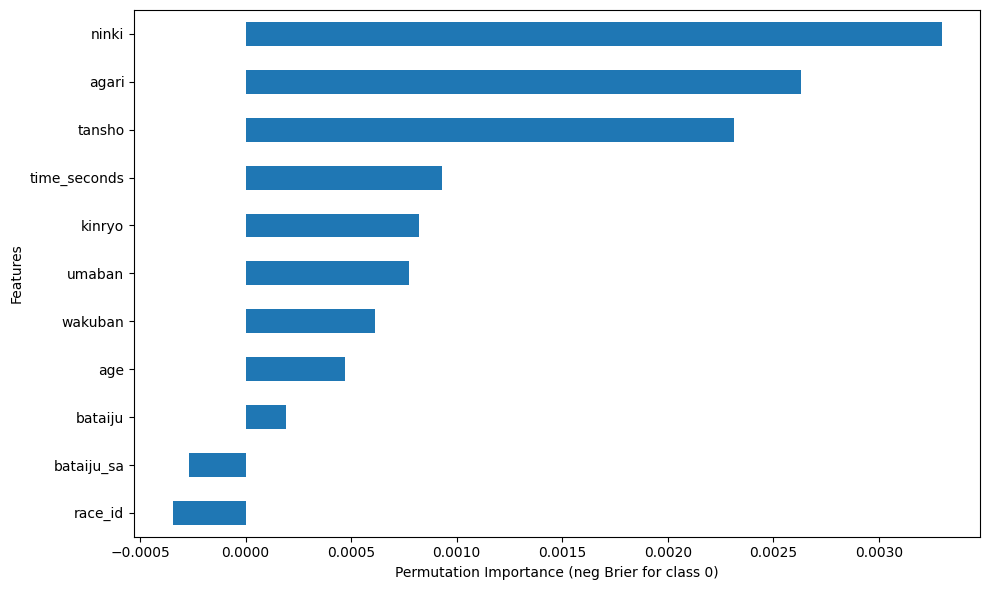

In [13]:
features = x_train.columns

def neg_brier_class0(estimator, X, y):
    # p0 を必ず 1次元 numpy にする
    p0 = np.asarray(estimator.predict_proba(X)[:, 0], dtype=float).ravel()

    # y を必ず 1次元 numpy にする（pandasでもnumpyでもOK）
    y_arr = np.asarray(y).ravel()

    # class0なら1、それ以外0（1次元）
    y0 = (y_arr == 0).astype(float)

    # Brier（1次元同士なので絶対に崩れない）
    brier = np.mean((p0 - y0) ** 2)
    return -brier

perm_importance = permutation_importance(
    svm_model,
    x_test,
    y_test,
    scoring=neg_brier_class0,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

svm_imp = pd.Series(
    perm_importance.importances_mean,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
svm_imp.plot(kind="barh")
plt.xlabel("Permutation Importance (neg Brier for class 0)")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## SHAP値

PermutationExplainer explainer: 301it [17:51,  3.59s/it]                         


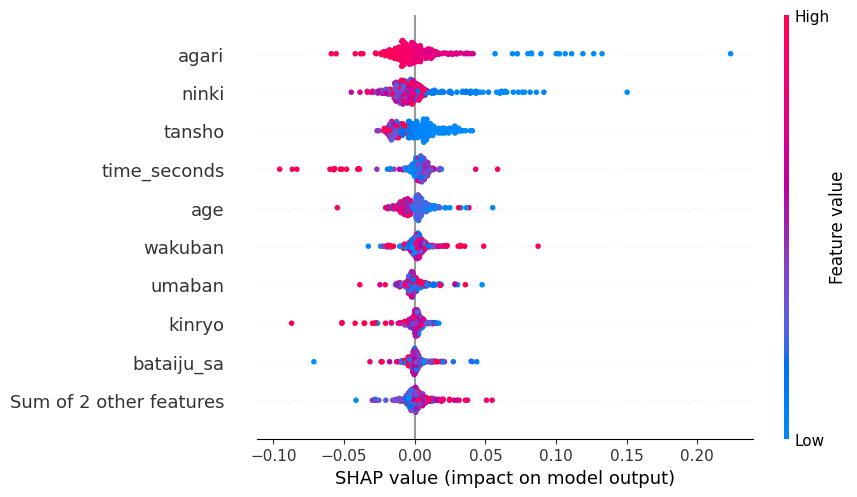

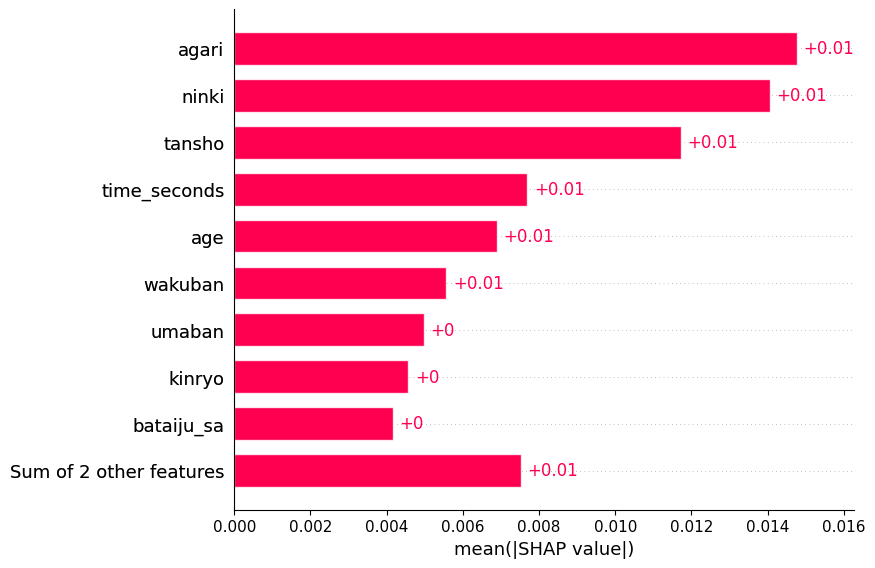

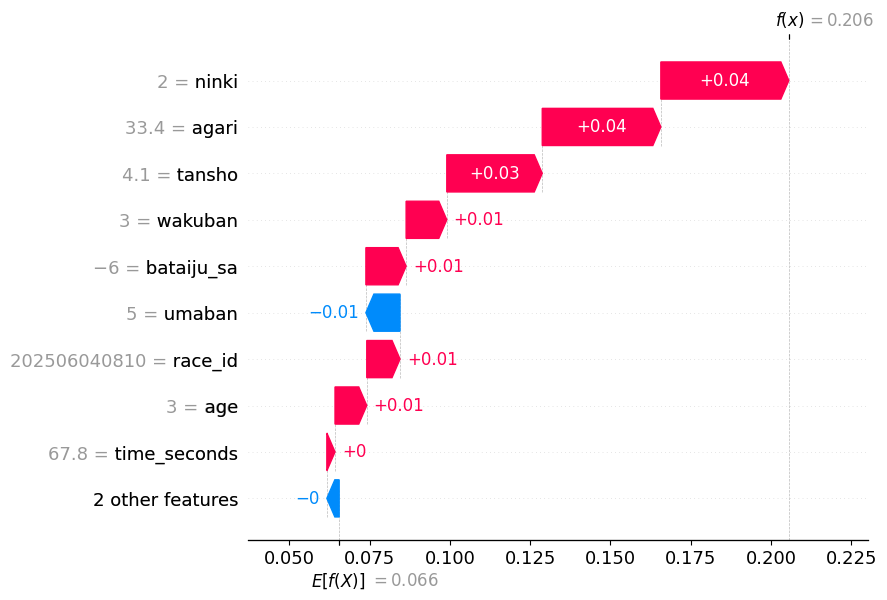

In [16]:
if hasattr(x_train, "sample"):
    X_bg = x_train.sample(n=min(50, len(x_train)), random_state=42)
else:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x_train), size=min(50, len(x_train)), replace=False)
    X_bg = x_train[idx]

masker = shap.maskers.Independent(X_bg)

explainer_svm = shap.Explainer(svm_model.predict_proba, masker)

# 説明対象（小さめ）
if hasattr(x_test, "sample"):
    X_explain = x_test.sample(n=min(300, len(x_test)), random_state=42)
else:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(x_test), size=min(300, len(x_test)), replace=False)
    X_explain = x_test[idx]

shap_exp = explainer_svm(X_explain)

# クラス0を対象
if shap_exp.values.ndim == 3:
    shap_exp_c0 = shap_exp[:, :, 0]
else:
    shap_exp_c0 = shap_exp

# 1) beeswarm
shap.plots.beeswarm(shap_exp_c0)

# 2) bar
shap.plots.bar(shap_exp_c0)

# 3) waterfall（代表1件）
i = 0
shap.plots.waterfall(shap_exp_c0[i])